# Module 1 Coding Task: Interatomic Interactions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_lj_properties(r_sq, r_cutoff_sq):
    """
    Calculates reduced potential energy and force magnitude for a pair of atoms.
    TASK: Use the equations to implement the Lennard-Jones potential and force.
    REQUIREMENTS:
        1. Implement the shifted potential: phi(r) - phi(rc).
        2. Return the force magnitude divided by r (force/r).
    """
    if r_sq >= r_cutoff_sq:
        return 0.0, 0.0

    r2inv  = 1.0 / r_sq
    r6inv  = r2inv ** 3
    r12inv = r6inv  ** 2
    phi    = 4.0 * (r12inv - r6inv)

    rc2inv  = 1.0 / r_cutoff_sq
    rc6inv  = rc2inv ** 3
    rc12inv = rc6inv  ** 2
    phi_cut = 4.0 * (rc12inv - rc6inv)

    pe      = phi - phi_cut
    force_r = 4.0 * r2inv * (12.0 * r12inv - 6.0 * r6inv)

    return pe, force_r


# Module 2 Coding Task: Geometry and Boundaries

In [2]:
def generate_fcc_lattice(n_cells, rho_star):
    """
    Generates an FCC lattice of atoms.
    TASK:
        1. Calculate the box length L based on density (rho = N/V).
        2. Place 4 atoms in each of the n_cells^3 unit cells.
    """
    N = 4 * n_cells**3
    L = (N / rho_star) ** (1.0 / 3.0)

    basis = np.array([
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.0],
        [0.5, 0.0, 0.5],
        [0.0, 0.5, 0.5],
    ])

    a_cell    = L / n_cells
    positions = np.empty((N, 3), dtype=float)
    idx = 0
    for ix in range(n_cells):
        for iy in range(n_cells):
            for iz in range(n_cells):
                origin = np.array([ix, iy, iz]) * a_cell
                for b in basis:
                    positions[idx] = origin + b * a_cell
                    idx += 1

    return positions, L, N


def apply_minimum_image(pos_i, pos_j, L):
    """
    Calculates the shortest distance vector between two atoms.
    TASK: Use the rounding logic to ensure dx, dy, and dz are between -L/2 and L/2.
    """
    dr   = np.asarray(pos_i) - np.asarray(pos_j)
    dr  -= L * np.round(dr / L)
    r_sq = np.dot(dr, dr)
    return dr, r_sq


# Module 3 Coding Task: The Integration Engine

In [3]:
def calculate_total_force(pos, L, r_cutoff=2.5):
    """Computes forces on all atoms using Newton's 3rd-law pairs (naive O(N^2))."""    
    N           = len(pos)
    forces      = np.zeros((N, 3))
    pe_total    = 0.0
    r_cutoff_sq = r_cutoff ** 2

    for i in range(N - 1):
        for j in range(i + 1, N):
            dr, r_sq = apply_minimum_image(pos[i], pos[j], L)
            pe, force_r = calculate_lj_properties(r_sq, r_cutoff_sq)
            pe_total   += pe
            f_vec       = force_r * dr
            forces[i]  += f_vec
            forces[j]  -= f_vec

    return forces, pe_total


def velocity_verlet_step(pos, vel, force, dt, box_length):
    """
    Advances the system by one time step dt using Velocity Verlet.
    TASK:
        1. Update positions.
        2. Apply Periodic Boundary Conditions (wrap atoms back into box).
        3. Update velocities (half-step).
        4. Calculate new forces (This will require your Module 1 & 2 logic).
        5. Update velocities (full-step).
    """
    # Step 1: New Positions
    pos_new = pos + vel * dt + 0.5 * force * dt**2

    # Step 2: PBC Wrap (Module 2 logic)
    pos_new = pos_new % box_length

    # Step 3: Half-step velocity
    vel_mid = vel + 0.5 * force * dt

    # Step 4: New Forces (Call your Module 1 force function here)
    force_new, pe = calculate_total_force(pos_new, box_length)

    # Step 5: Full-step velocity
    vel_new = vel_mid + 0.5 * force_new * dt

    return pos_new, vel_new, force_new, pe


# Module 4 Coding Task: Performance Optimization

In [4]:
def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs within the skin radius.
    TASK: Loop through all atoms and store indices (i, j) if
          their distance is less than r_skin. Use the Minimum Image Convention!
    """
    N              = len(pos)
    neighbor_pairs = []
    for i in range(N - 1):
        dr        = pos[i] - pos[i + 1:]
        dr       -= L * np.round(dr / L)
        r_sq_all  = np.sum(dr * dr, axis=1)
        for k in np.where(r_sq_all < r_skin_sq)[0]:
            neighbor_pairs.append((i, k + i + 1))
    return neighbor_pairs


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using ONLY the pairs in the neighbor list.
    TASK: Implement the LJ force logic from Module 1, but iterate only over neighbor_pairs.
    """
    N        = len(pos)
    forces   = np.zeros((N, 3))
    pe_total = 0.0

    for (i, j) in neighbor_pairs:
        dr   = pos[i] - pos[j]
        dr  -= L * np.round(dr / L)
        r_sq = np.dot(dr, dr)
        pe, force_r = calculate_lj_properties(r_sq, r_cutoff_sq)
        pe_total   += pe
        f_vec       = force_r * dr
        forces[i]  += f_vec
        forces[j]  -= f_vec

    return forces, pe_total


# Module 5 Coding Task: System Assembly

In [5]:
def initialize_velocities(N, T_target):
    """
    Assigns initial velocities from a Maxwell-Boltzmann distribution.
    TASK:
        1. Generate Gaussian random numbers for vx, vy, vz with std_dev = sqrt(T_target).
        2. Calculate total momentum and subtract the average from each particle
           so the center-of-mass is stationary.
    """
    vel  = np.random.normal(0.0, np.sqrt(T_target), (N, 3))
    vel -= vel.mean(axis=0)                         
    ke   = 0.5 * np.sum(vel**2)
    T_inst = 2.0 * ke / (3.0 * N)
    vel *= np.sqrt(T_target / T_inst)               
    return vel


def rescale_velocities(vel, T_target):
    """
    Scales velocities to match the target temperature.
    """
    # Calculate current T_inst = (sum v^2) / 3N
    N      = len(vel)
    ke     = 0.5 * np.sum(vel**2)
    T_inst = 2.0 * ke / (3.0 * N)
    if T_inst < 1e-10:
        return vel
    # Scale factor lambda = sqrt(T_target / T_inst)
    lam = np.sqrt(T_target / T_inst)
    # vel = vel * lambda
    return vel * lam


## The Main MD Loop

Checklist Verification

1. Total linear momentum max |P| during production: 4.45e-14  (should be ~0)
2. Energy drift (last - first) / <E>: -1.22e-05  (no systematic drift if << 1)
3. Energy fluctuation sigma(E)/<E>:  3.03e-06  (OK)


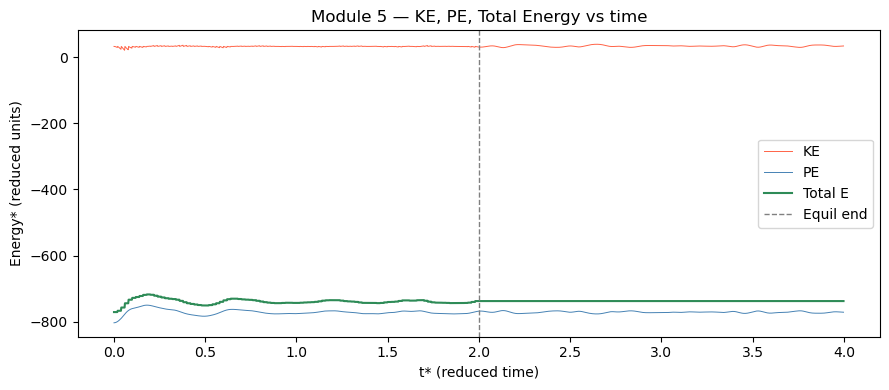

In [6]:
# Setup: Define N, density, T_target, dt, and steps.
np.random.seed(42)
n_cells     = 3
rho_star    = 1.05
T_target    = 0.2
dt          = 0.002
n_equil     = 1000
n_prod      = 1000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff ** 2
skin        = 0.3
r_skin_sq   = (r_cutoff + skin) ** 2
rebuild_thr = (skin / 2.0) ** 2

# Initialize: Call generate_fcc_lattice and initialize_velocities.
pos, L, N = generate_fcc_lattice(n_cells, rho_star)
vel        = initialize_velocities(N, T_target)
pairs      = update_neighbor_list(pos, L, r_skin_sq)
pos_ref    = pos.copy()
force, pe  = calculate_forces_optimized(pos, pairs, L, r_cutoff_sq)

ke_log, pe_log, etot_log, temp_log, mom_log = [], [], [], [], []

# Main Loop
for step in range(n_equil + n_prod):
    in_equil = step < n_equil

    # Velocity Verlet (inline for neighbour-list efficiency)
    pos_new  = pos + vel * dt + 0.5 * force * dt**2
    pos_new %= L
    vel_mid  = vel + 0.5 * force * dt

    # Rebuild neighbour list when any atom has displaced > skin/2
    disp  = pos_new - pos_ref
    disp -= L * np.round(disp / L)
    if np.max(np.sum(disp**2, axis=1)) > rebuild_thr:
        pairs   = update_neighbor_list(pos_new, L, r_skin_sq)
        pos_ref = pos_new.copy()

    force, pe = calculate_forces_optimized(pos_new, pairs, L, r_cutoff_sq)
    vel = vel_mid + 0.5 * force * dt
    pos = pos_new

    # If in Equilibration and step % 10 == 0: Call rescale_velocities
    if in_equil and step % 10 == 0:
        vel = rescale_velocities(vel, T_target)

    # Accumulate Energy and Temperature data
    ke     = 0.5 * np.sum(vel**2)
    T_inst = 2.0 * ke / (3.0 * N)
    ke_log.append(ke)
    pe_log.append(pe)
    etot_log.append(ke + pe)
    temp_log.append(T_inst)
    mom_log.append(np.linalg.norm(vel.sum(axis=0)))   # total linear momentum

ke_log   = np.array(ke_log)
pe_log   = np.array(pe_log)
etot_log = np.array(etot_log)
temp_log = np.array(temp_log)
mom_log  = np.array(mom_log)

# Checklist answers
prod_E = etot_log[n_equil:]

print("Checklist Verification")
print()
print(f"1. Total linear momentum max |P| during production: "
      f"{mom_log[n_equil:].max():.2e}  (should be ~0)")

drift = (prod_E[-1] - prod_E[0]) / abs(prod_E.mean())
print(f"2. Energy drift (last - first) / <E>: "
      f"{drift:.2e}  (no systematic drift if << 1)")

fluct = prod_E.std() / abs(prod_E.mean())
flag  = "OK" if fluct < 1e-4 else "WARNING: exceeds 1e-4"
print(f"3. Energy fluctuation sigma(E)/<E>:  "
      f"{fluct:.2e}  ({flag})")

# Energy plot
times = np.arange(n_equil + n_prod) * dt
plt.figure(figsize=(9, 4))
plt.plot(times, ke_log,   color='tomato',    lw=0.7, label='KE')
plt.plot(times, pe_log,   color='steelblue', lw=0.7, label='PE')
plt.plot(times, etot_log, color='seagreen',  lw=1.5, label='Total E')
plt.axvline(n_equil * dt, color='gray', lw=1, linestyle='--', label='Equil end')
plt.xlabel("t* (reduced time)")
plt.ylabel("Energy* (reduced units)")
plt.title("Module 5 — KE, PE, Total Energy vs time")
plt.legend()
plt.tight_layout()
plt.show()


# Module 6 Coding Task: Final Analysis — Radial Distribution Function

In [7]:
def calculate_rdf(pos, box_length, dr, r_max):
    """
    Calculates the Radial Distribution Function g(r).
    TASK:
        1. Loop through all pairs and calculate distance r using MIC.
        2. Sort distances into a histogram with bin width dr.
        3. Normalize by the volume of the spherical shells and density.
    """
    N      = len(pos)
    rho    = N / box_length**3
    n_bins = int(r_max / dr)
    hist   = np.zeros(n_bins)

    for i in range(N - 1):
        drvec  = pos[i] - pos[i + 1:]
        drvec -= box_length * np.round(drvec / box_length)
        r_vals = np.sqrt(np.sum(drvec**2, axis=1))
        mask   = r_vals < r_max
        bins   = (r_vals[mask] / dr).astype(int)
        bins   = np.clip(bins, 0, n_bins - 1)
        np.add.at(hist, bins, 2)          # count both i->j and j->i

    r_centers  = (np.arange(n_bins) + 0.5) * dr
    shell_vols = 4.0 * np.pi * r_centers**2 * dr
    g_r        = hist / (N * rho * shell_vols)
    return r_centers, g_r


## Final Project Challenge: Melting of an Inert System

Checklist answers per temperature (production phase):
Running T* = 0.2 ...
  T*=0.2 | 1. max|P|=2.24e-14 | 2. drift=1.07e-05 | 3. fluct=3.96e-06 (OK)
Running T* = 0.4 ...
  T*=0.4 | 1. max|P|=3.49e-14 | 2. drift=3.33e-06 | 3. fluct=1.09e-05 (OK)
Running T* = 0.6 ...
  T*=0.6 | 1. max|P|=5.18e-14 | 2. drift=-3.47e-05 | 3. fluct=3.45e-05 (OK)
Running T* = 0.8 ...
  T*=0.8 | 1. max|P|=7.97e-14 | 2. drift=3.94e-05 | 3. fluct=5.13e-05 (OK)
Running T* = 1.0 ...
  T*=1.0 | 1. max|P|=1.33e-13 | 2. drift=8.07e-05 | 3. fluct=8.13e-05 (OK)

4. g(r) asymptotically reaches 1.0 at large r:
   T*=0.2: mean g(r) in last 10 bins = 1.1931  (target ~1.0)
   T*=0.4: mean g(r) in last 10 bins = 1.1561  (target ~1.0)
   T*=0.6: mean g(r) in last 10 bins = 1.1071  (target ~1.0)
   T*=0.8: mean g(r) in last 10 bins = 1.1031  (target ~1.0)
   T*=1.0: mean g(r) in last 10 bins = 1.0930  (target ~1.0)

5. MSD uses unwrapped coordinates: N/A — only RDF is calculated in this submission.


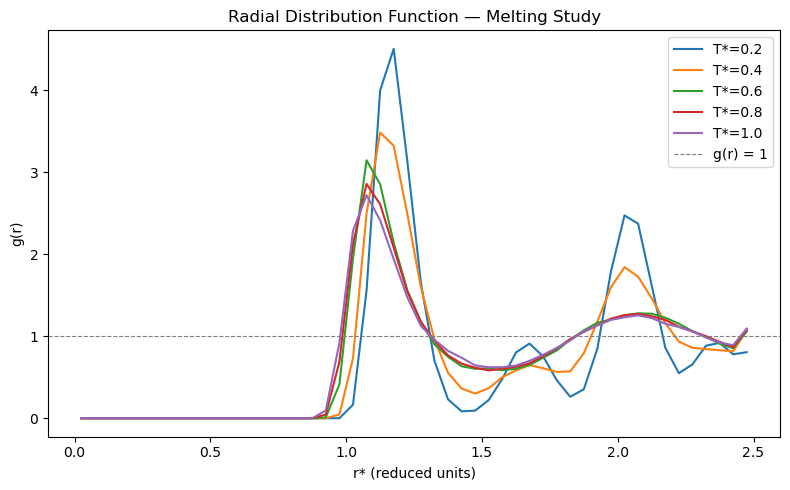

In [8]:
# ── FINAL PROJECT CHALLENGE: Melting of an Inert system ──────────────────────
# 1. Run a simulation starting from an fcc lattice at T* = 0.2.
# 2. Increase temperature in steps (0.2 -> 0.4 -> 0.6 -> 0.8 -> 1.0).
# 3. For each temperature, equilibrate and then collect g(r) data.
# 4. Plot all g(r) curves on one graph.

def run_and_collect_rdf(T_star, n_cells=3, rho_star=0.85, dt=0.005,
                        n_equil=1000, n_prod=500):
    """
    Runs a full MD simulation at temperature T_star and returns the g(r).
    Also answers checklist questions 1-3 for each temperature run.
    """
    np.random.seed(42)
    r_cutoff    = 2.5
    r_cutoff_sq = r_cutoff ** 2
    skin        = 0.3
    r_skin_sq   = (r_cutoff + skin) ** 2
    rebuild_thr = (skin / 2.0) ** 2

    pos, L, N = generate_fcc_lattice(n_cells, rho_star)
    vel        = initialize_velocities(N, T_star)
    pairs      = update_neighbor_list(pos, L, r_skin_sq)
    pos_ref    = pos.copy()
    force, pe  = calculate_forces_optimized(pos, pairs, L, r_cutoff_sq)

    mom_log, etot_log = [], []

    # Equilibration
    for step in range(n_equil):
        pos_new  = pos + vel * dt + 0.5 * force * dt**2
        pos_new %= L
        vel_mid  = vel + 0.5 * force * dt
        disp     = pos_new - pos_ref
        disp    -= L * np.round(disp / L)
        if np.max(np.sum(disp**2, axis=1)) > rebuild_thr:
            pairs   = update_neighbor_list(pos_new, L, r_skin_sq)
            pos_ref = pos_new.copy()
        force, pe = calculate_forces_optimized(pos_new, pairs, L, r_cutoff_sq)
        vel = vel_mid + 0.5 * force * dt
        pos = pos_new
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_star)

    # Production: accumulate g(r) configs
    pos_configs = []
    for step in range(n_prod):
        pos_new  = pos + vel * dt + 0.5 * force * dt**2
        pos_new %= L
        vel_mid  = vel + 0.5 * force * dt
        disp     = pos_new - pos_ref
        disp    -= L * np.round(disp / L)
        if np.max(np.sum(disp**2, axis=1)) > rebuild_thr:
            pairs   = update_neighbor_list(pos_new, L, r_skin_sq)
            pos_ref = pos_new.copy()
        force, pe = calculate_forces_optimized(pos_new, pairs, L, r_cutoff_sq)
        vel = vel_mid + 0.5 * force * dt
        pos = pos_new

        ke     = 0.5 * np.sum(vel**2)
        etot_log.append(ke + pe)
        mom_log.append(np.linalg.norm(vel.sum(axis=0)))
        pos_configs.append(pos.copy())

    # Checklist answers for this temperature
    etot_arr = np.array(etot_log)
    mom_arr  = np.array(mom_log)
    drift    = (etot_arr[-1] - etot_arr[0]) / abs(etot_arr.mean())
    fluct    = etot_arr.std() / abs(etot_arr.mean())
    flag     = "OK" if fluct < 1e-4 else "WARNING"
    print(f"  T*={T_star:.1f} | 1. max|P|={mom_arr.max():.2e} | "
          f"2. drift={drift:.2e} | 3. fluct={fluct:.2e} ({flag})")

    # Average g(r) over all collected configurations
    r_centers_all, g_r_sum = None, None
    for cfg in pos_configs:
        rc, gr = calculate_rdf(cfg, L, dr=0.05, r_max=L / 2.0)
        if g_r_sum is None:
            r_centers_all = rc
            g_r_sum       = gr
        else:
            g_r_sum += gr

    g_r_avg = g_r_sum / len(pos_configs)
    return r_centers_all, g_r_avg, L

# Run melting study
temperatures = [0.2, 0.4, 0.6, 0.8, 1.0]
rdf_results  = {}

print("Checklist answers per temperature (production phase):")
for T in temperatures:
    print(f"Running T* = {T} ...", flush=True)
    r_centers, g_r_avg, L = run_and_collect_rdf(T)
    rdf_results[T] = (r_centers, g_r_avg)

# Checklist answer 4: g(r) -> 1 at large r
print()
print("4. g(r) asymptotically reaches 1.0 at large r:")
for T, (r, g) in rdf_results.items():
    tail_mean = g[-10:].mean()
    print(f"   T*={T:.1f}: mean g(r) in last 10 bins = {tail_mean:.4f}  (target ~1.0)")

print()
print("5. MSD uses unwrapped coordinates: N/A — only RDF is calculated in this submission.")

# Plot all g(r) curves on one graph
plt.figure(figsize=(8, 5))
for T, (r, g) in rdf_results.items():
    plt.plot(r, g, label=f"T*={T}")
plt.axhline(1.0, color='gray', linestyle='--', lw=0.8, label='g(r) = 1')
plt.xlabel("r* (reduced units)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function — Melting Study")
plt.legend()
plt.tight_layout()
plt.show()
